# Mean correction effect

In [21]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
c0 ={'acc':'#941717', 'cor':'#388E3C','ggd':'#42A5F5', 'wd':'#FFA000', 'sum':'lightgrey'}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square

In [22]:
N=100000

In [23]:
closure_vars = ['ACC*', 'COR*', 'GGD*', 'WD*', 'S*', 'sigma*'] + ['B*_'+v for v in ['acc', 'cor', 'ggd', 'wd']] + ['E*_'+v for v in ['acc', 'cor', 'ggd', 'wd']] + ['X*_acc_cor', 'X*_acc_ggd', 'X*_acc_wd', 'X*_cor_ggd', 'X*_cor_wd', 'X*_ggd_wd'] + ['D*_cyclo', 'D*_anticyclo']

def compute_mean_square_1D(ds):
    """ Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """

    closure_vars_=closure_vars
    
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    if 'meancor' in ds :
        print('ok')
        var += ['meancor', 'meanggd']
        VAR += ['meancor'.upper(), 'meanggd'.upper()]
        closure_vars_ = closure_vars +['MEANCOR*', 'MEANGGD*']
        
    dss = (ds[[v for v in var]]**2).rename({var[i] : VAR[i] for i in range(len(var))})
    dss['sigma'] = dss['ACC'] + dss['COR'] + dss['GGD'] + dss['WD']
    
    nb_coloc = len(ds.row_number)
    
    #Balanced and error

    for v in ['acc', 'cor', 'ggd', 'wd'] : 
        dss['B'+'_'+v] = -((ds[v]*ds['exc'+'_'+v]))
        dss['E'+'_'+v] = ((ds[v]*ds['sum']))
            
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v]

    # Cyclo/anticyclo contribution
    dss['D'+'_cyclo'] = -2 *(ds['acc']+ds['cor'])*ds['ggd']
    dss['D'+'_anticyclo'] = -2 *(ds['acc']+ds['ggd'])*ds['cor']

    # Mean
    dsm = dss.mean('row_number')
    
    # Add errors central limit
    dsse = (2*dss.std('row_number')/np.sqrt(nb_coloc)).rename({v:'ser__'+v for v in list(dss.keys())})

    dss = xr.merge([dsm, dsse])

    #Mean geostrophics corrections :
    if 'meancor' in ds :
        print('geostrophic mean corrections')

        for v in ['cor', 'ggd']:
            dss[v.upper() ] = dss[v.upper() ] + dss['MEAN'+ v.upper() ]
            dss['B'+'_'+v] = dss['B'+'_'+v] + dss['MEAN'+ v.upper() ]
            dss['X'+'_cor_ggd'] = dss['X'+'_cor_ggd'] + 2*dss['MEAN'+ v.upper() ]
        for v in ['cor', 'ggd']:
            dss[v.upper()] =  dss[v.upper() + dirname[0]]
            dss['B_'+v] = dss['B'+'_'+v] 
            dss['X_cor_ggd'] = dss['X'+'_cor_ggd']
        
    #end
    from diagnosis import assign_attrs
    dss = assign_attrs(dss,[''])
    return dss

def build_dataset(a, b, c, d, row):
    ds = xr.Dataset(
        data_vars=dict(
            acc=("row_number", a),
            cor=("row_number", b),
            ggd=("row_number", c),
            wd=("row_number", d),
        ), 
        coords=dict(row_number=("row_number", row)
                   )
    )
    ds['sum'] = ds.acc + ds.cor + ds.ggd +ds.wd

    # simple var + sum- one term
    for v in ['acc', 'cor', 'ggd', 'wd'] :
        ds['exc_'+v] = ds['sum']-ds[v]

    #2 by 2 product    
    import itertools  
    couple = list(itertools.combinations(['acc', 'cor', 'ggd', 'wd'],2))
    for c in couple : 
        ds['prod'+'_'+'_'.join(c)] = ds[c[0]] * ds[c[1]]
    
    return ds

def plot_terms(ds):
    fig, axs = plt.subplots(1, 5, sharey=True, frameon=False, figsize=(10,3))
    i=0
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        ds[var].plot(ax=axs[i], color = c0[var])
        i+=1
    for ax in axs :
        ax.grid()


def plot_diag(fig, ax, ds, ds2):
    plt.rcParams["axes.edgecolor"] = "k"
    df = ds.to_dataframe()
    var = ['acc', 'cor', 'ggd', 'wd']
    i=0
    for v in var:
        # total MS
        ax.bar(i, ds2[v.upper()], color=c0[v], alpha=0.5)
    
        #B and E
        if ds2['B_'+v] > 0 : 
            ax.bar(i, ds2['B_'+v], color=c0[v], width=0.7)
            if ds2['E_'+v]< 0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=0.7)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=0.7)
        else :
            ax.bar(i, ds2['B_'+v], color=c0[v], width=0.7)
            if ds2['E_'+v]>0 : ax.bar(i, ds2['E_'+v], color='lightgrey', width=0.7)
            else : ax.bar(i, ds2['E_'+v],bottom = ds2['B_'+v], color='lightgrey', width=0.7)
                
        #X
        X_var = [x for x in ds2 if (('X_' in x)&(v in x)&('ser_' not in x))]
        pos_X = [ x for x in X_var if ds2[x]>0]
        neg_X = [ x for x in X_var if x not in pos_X]
    
        sum_posX = 0
        for X in pos_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_posX, color = c0[xc[1]], hatch="/", width=0.5)
            sum_posX += ds2[X]/2
    
        sum_negX = 0
        for X in neg_X :
            xc =X.replace('X_', '').split('_')
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(i, ds2[X]/2, bottom = sum_negX, color = c0[xc[1]], hatch="/", width=0.5)
            sum_negX += ds2[X]/2
        i+=1
    ax.bar(i, ds2['S'], color = 'lightgrey')
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    

def plot_total_diag(a, b, c, d, row):
    
    ds = build_dataset(a, b, c, d, row)

    ds['row_number'] = ds['row_number'].assign_attrs({'long_name':'Colocations'})
    ds['acc'] = ds['acc'].assign_attrs({'long_name':'A', 'unit':r'$\gamma$'})
    ds['cor'] = ds['cor'].assign_attrs({'long_name':'B', 'unit':r'$\gamma$'})
    ds['ggd'] = ds['ggd'].assign_attrs({'long_name':'C', 'unit':r'$\gamma$'})
    ds['wd'] = ds['wd'].assign_attrs({'long_name':'D', 'unit':r'$\gamma$'})
    ds['sum'] = ds['sum'].assign_attrs({'long_name':'Residual', 'unit':r'$\gamma$'})

    ds2 = compute_mean_square_1D(ds)

    from matplotlib.gridspec import GridSpec
    fig = plt.figure( frameon=False, figsize = (13, 6))
    gs = GridSpec(2, 5, figure=fig)

    # Visualize row series
    i=0
    ax0 = fig.add_subplot(gs[0, i])
    for var in ['acc', 'cor','ggd','wd', 'sum']:
        ax = fig.add_subplot(gs[0, i], sharey=ax0)
        ds[var].plot(ax=ax, color = c0[var])
        ax.axhline(ds[var].mean(dim='row_number'), ls = '--', color='k')
        ax.grid()
        i+=1
    # Reconstruction data
    ax = fig.add_subplot(gs[1, :])
    plot_diag(fig, ax, ds, ds2)
    ax.set_xticks(ticks = np.arange(5),labels =['Lagrangian \n acceleration', 'Coriolis \n accelration', 'Pressure \n gradient term', 'Wind','Residual'])
    #ax.set_xticks(ticks = np.arange(5),labels = ['A', 'B', 'C', 'D','Residual'] )
    fig.tight_layout()
    
    return ds, ds2

__________________________
# 1. No noise
## 1.1. No mean - no correction

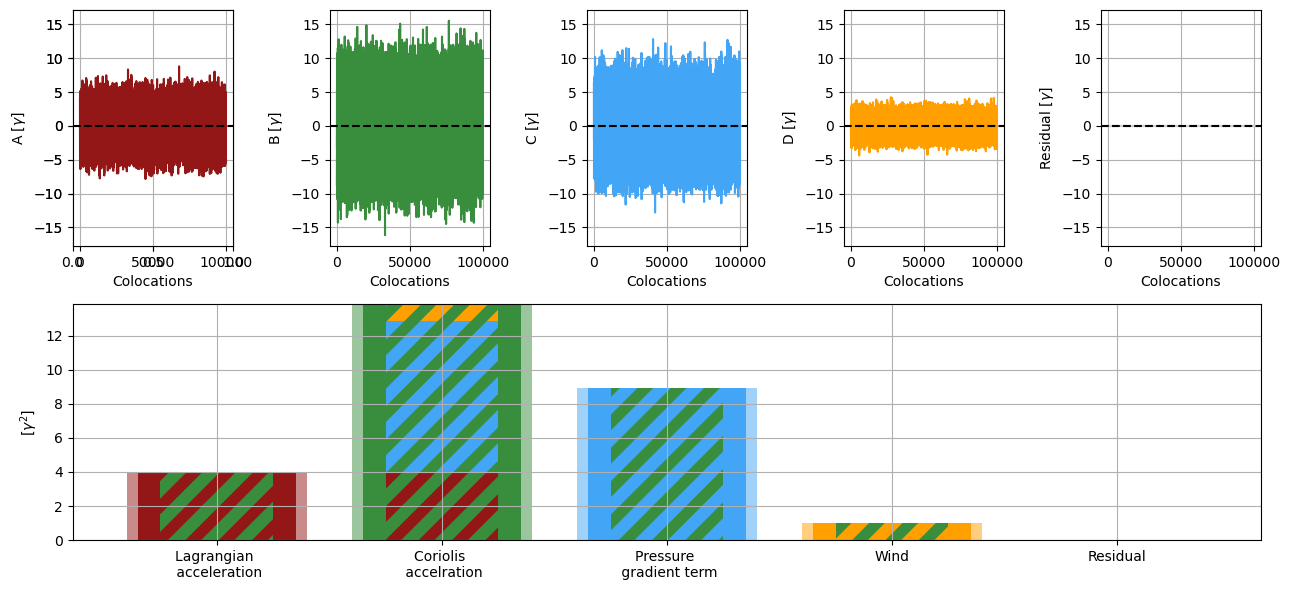

In [24]:
std = [2, 3, 1, 1.3]
mean = [0,0,0,0]
row = np.arange(0, N)

ab = np.random.normal(0, std[0], N)
bc = np.random.normal(0, std[1], N)
bd = np.random.normal(0, std[2], N)

a = ab
b = -bc-ab-bd
c = bc
d = bd
#d = np.random.normal(0, std[3], N)

ds, ds2 = plot_total_diag(a, b, c, d, row)


## 1.2. With mean - no correction

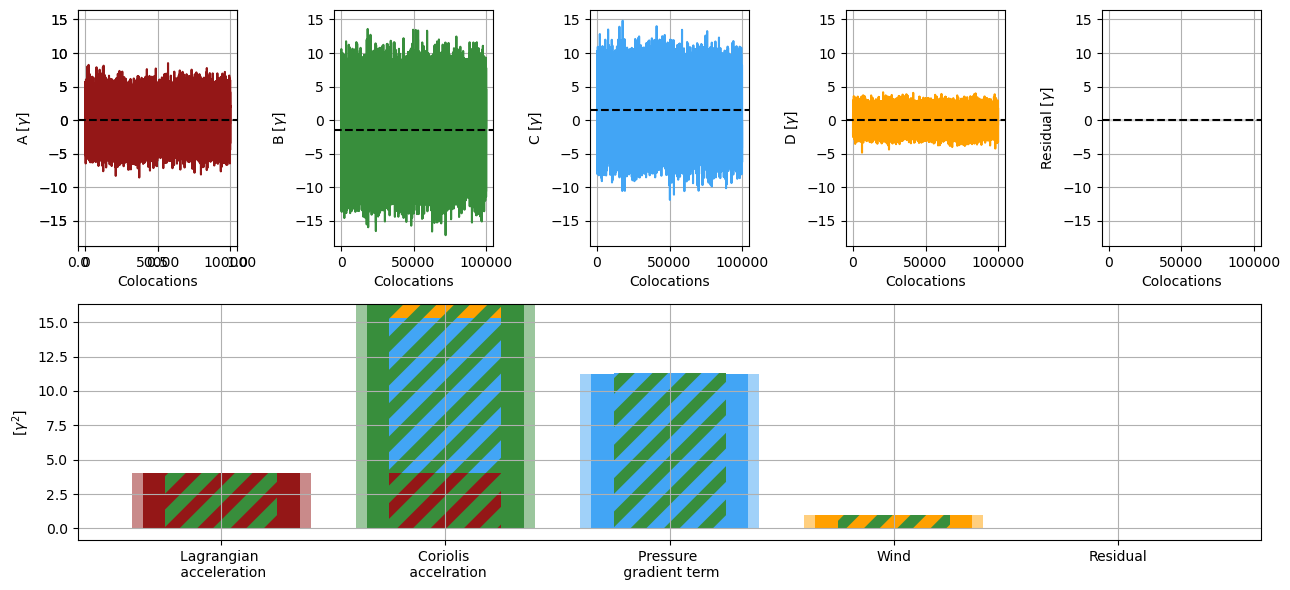

In [33]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(0, std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(0, std[2], N)

a = ab
b = -bc-ab-bd
c = bc
d = bd
#d = np.random.normal(0, std[3], N)

ds, ds2 = plot_total_diag(a, b, c, d, row)

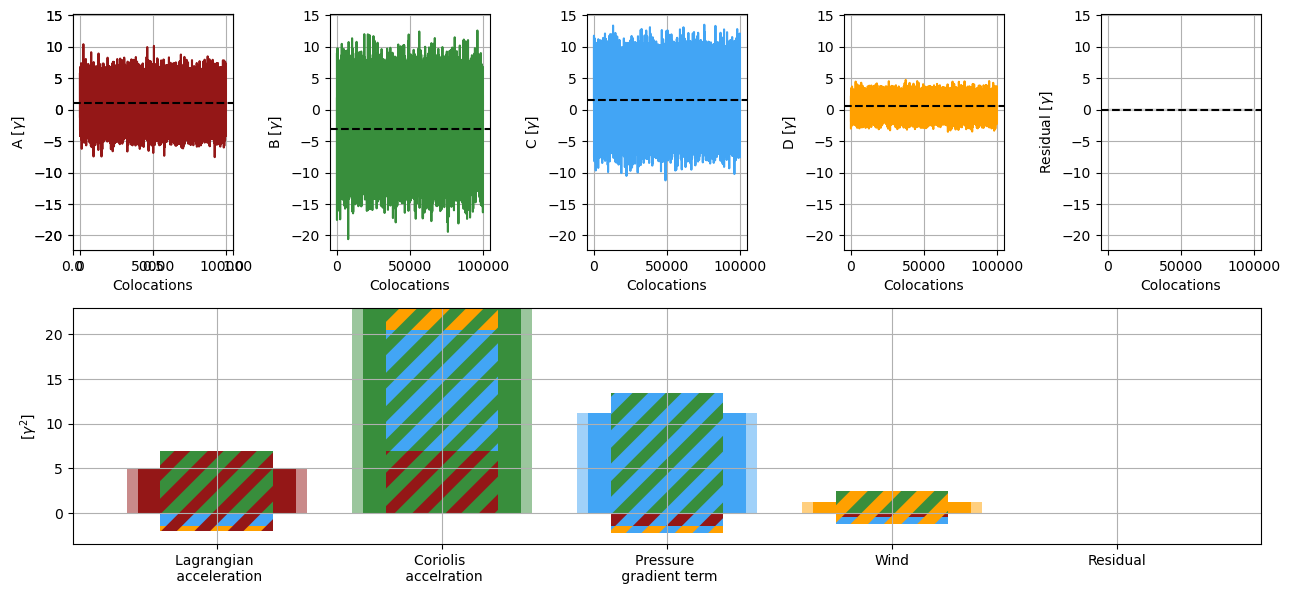

In [34]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)


ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)

a = ab
b = -bc-ab-bd
c = bc
d = bd
#d = np.random.normal(0, std[3], N)

ds, ds2 = plot_total_diag(a, b, c, d, row)


## 1.3. With mean - with correction

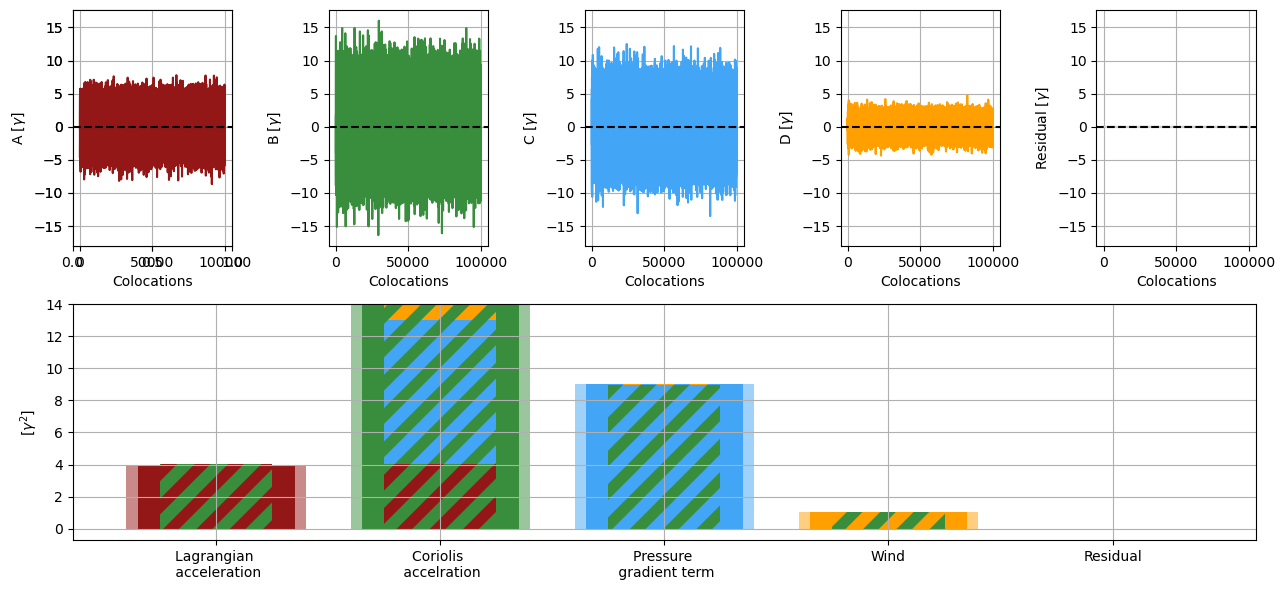

In [35]:
std = [2, 3, 1, 1.3]
mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)

a = ab 
b = -bc-ab-bd
c = bc
d = bd
#d = np.random.normal(0, std[3], N)

# correct
a = a -a.mean()
b = b -b.mean()
c = c -c.mean()
d = d -d.mean()

ds, ds2 = plot_total_diag(a, b, c, d, row)

_____________
# 2. With noise
## 2.1. No mean - no correction

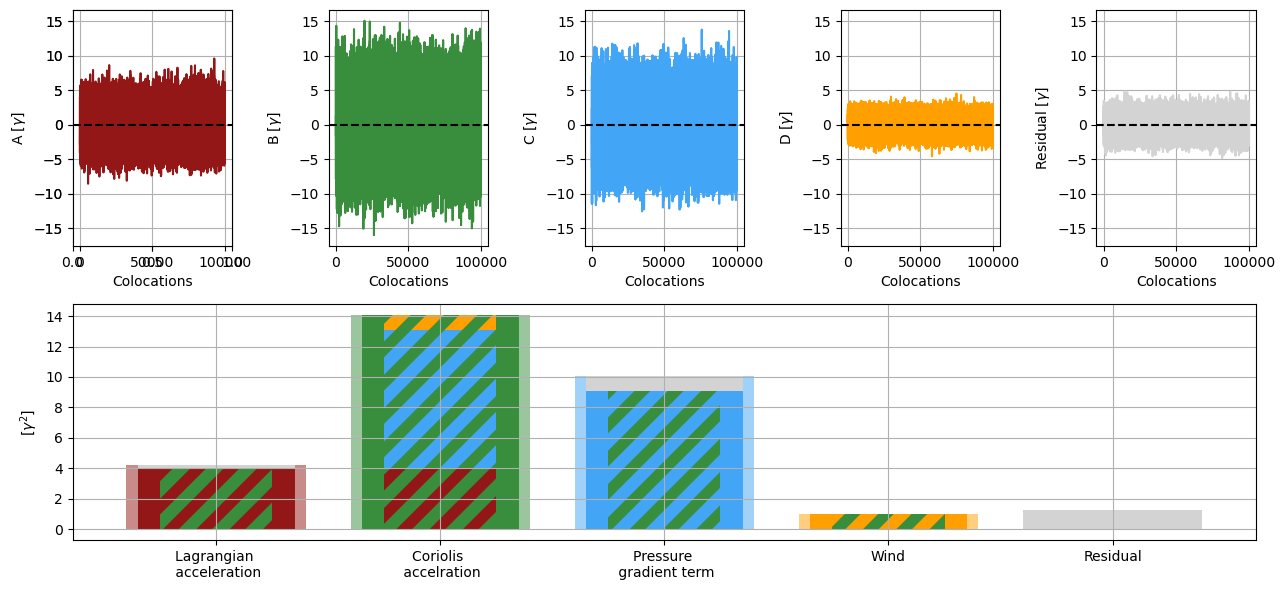

In [36]:
std = [2, 3, 1, 1.3]
stdnoise = [0.5,0,1,0]

mean = [0, 0, 0, 0]#np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)

a = ab +np.random.normal(0, stdnoise[0], N)
b = -bc-ab-bd +np.random.normal(0, stdnoise[1], N)
c = bc+np.random.normal(0, stdnoise[2], N)
d = bd+np.random.normal(0, stdnoise[3], N)
#d = np.random.normal(0, std[3], N)

ds, ds2 = plot_total_diag(a, b, c, d, row)

## 2.2. with mean - no correction

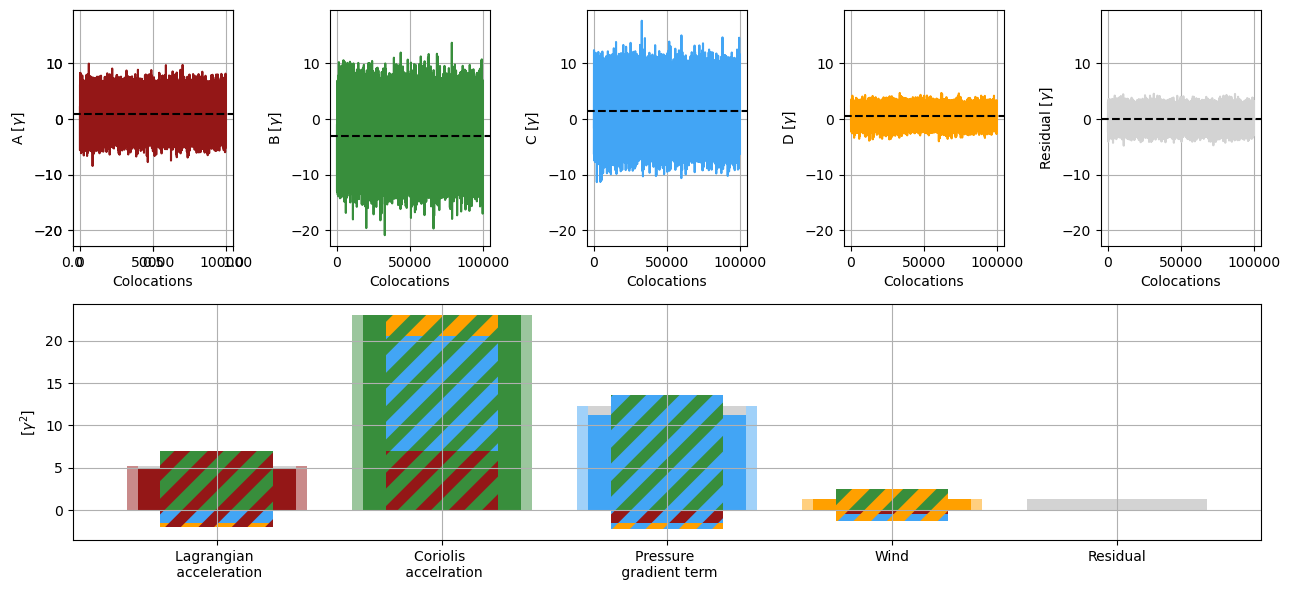

In [31]:
std = [2, 3, 1, 1.3]
stdnoise = [0.5,0,1,0]

mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)

a = ab +np.random.normal(0, stdnoise[0], N)
b = -bc-ab-bd +np.random.normal(0, stdnoise[1], N)
c = bc+np.random.normal(0, stdnoise[2], N)
d = bd+np.random.normal(0, stdnoise[3], N)
#d = np.random.normal(0, std[3], N)

ds, ds2 = plot_total_diag(a, b, c, d, row)

## 2.3. with mean - with mean correction

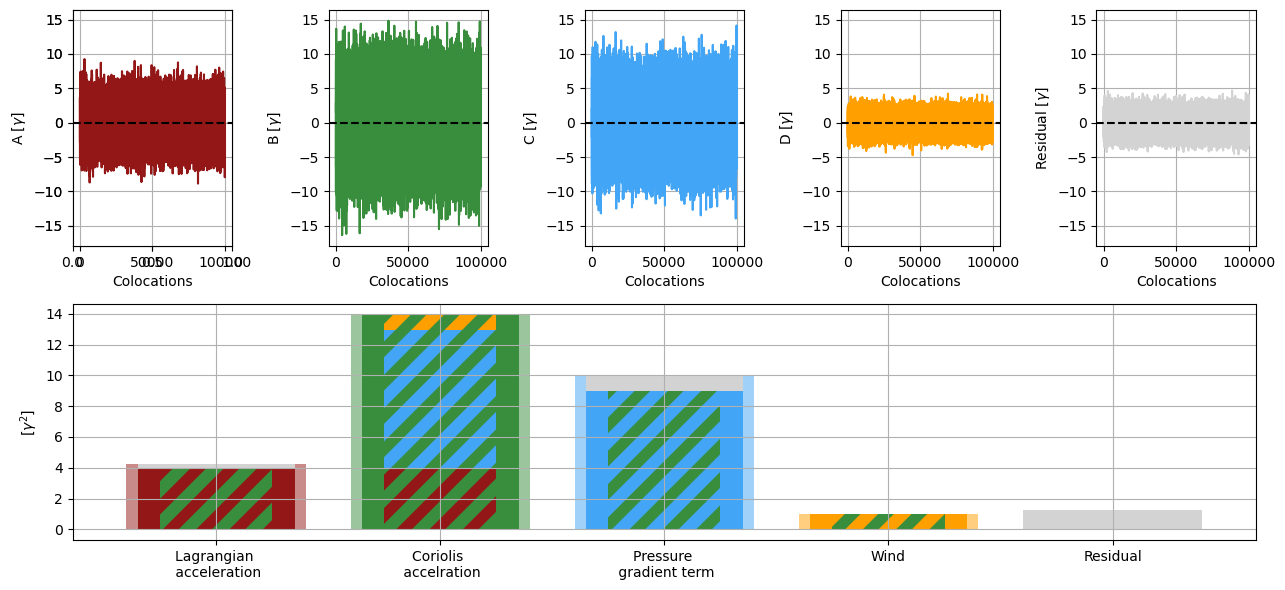

In [30]:
std = [2, 3, 1, 1.3]
stdnoise = [0.5,0,1,0]

mean = np.array(std)*0.5
row = np.arange(0, N)

ab = np.random.normal(mean[0], std[0], N)
bc = np.random.normal(mean[1], std[1], N)
bd = np.random.normal(mean[2], std[2], N)

a = ab +np.random.normal(0, stdnoise[0], N)
b = -bc-ab-bd +np.random.normal(0, stdnoise[1], N)
c = bc+np.random.normal(0, stdnoise[2], N)
d = bd+np.random.normal(0, stdnoise[3], N)
#d = np.random.normal(0, std[3], N)

# correct
a = a -a.mean()
b = b -b.mean()
c = c -c.mean()
d = d -d.mean()

ds, ds2 = plot_total_diag(a, b, c, d, row)